# 10-Fold Data Splitting - CAR

This notebook creates 10-fold cross-validation splits for **CAR** insurance modeling data.

**Configuration:**
- Data paths and column mappings are in `config.json`
- Objective function uses: BI, PD, PIP, COLL, COMP (excludes MED)

**Steps:**
1. Load configuration and data
2. Explore all 6 coverage distributions
3. Analyze BI vs PD relationship
4. Remove zero exposure records
5. Calculate Pure Premium
6. Run simulations to find optimal seed
7. Apply best seed and validate
8. Save output

## 1. Setup and Imports

In [32]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Import functions from utils.py
from utils import (
    load_config,
    load_and_merge_data,
    show_zero_exposure_stats,
    calculate_pure_premium,
    calculate_overall_stats,
    print_overall_stats,
    run_simulations,
    get_best_seed,
    plot_objective_distribution,
    plot_all_coverage_histograms,
    plot_incurred_histograms,
    analyze_bi_pd_relationship,
    assign_folds,
    validate_folds,
    save_output
)

# Load configuration
config = load_config('config.json')

print("="*60)
print("CAR - 10-Fold Configuration")
print("="*60)
print(f"\nFile paths:")
print(f"  Main data: {config['file_paths']['main_data_path']}")
print(f"  Superpolicy: {config['file_paths']['superpolicy_path']}")
print(f"  Output: {config['file_paths']['output_path']}")
print(f"\nSimulation parameters:")
print(f"  N_SIMULATIONS: {config['n_simulations']}")
print(f"  N_FOLDS: {config['n_folds']}")
print(f"\nCoverages:")
print(f"  All (for visualization): {config['all_coverages']}")
print(f"  For PP calculation: {config['analysis_coverages']}")
print(f"  For objective function: {config['objective_coverages']}")

CAR - 10-Fold Configuration

File paths:
  Main data: /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
  Superpolicy: /Users/Mach/dev/aps/data/2026_Dmodel_data/superpolicy/superpolicy_car.parquet
  Output: /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/car_master_dataset_10fold_sp.parquet

Simulation parameters:
  N_SIMULATIONS: 300
  N_FOLDS: 10

Coverages:
  All (for visualization): ['bi', 'pd', 'pip', 'med', 'coll', 'comp']
  For PP calculation: ['bi', 'pd', 'pip', 'coll', 'comp']
  For objective function: ['bi', 'pd', 'pip', 'coll', 'comp']


## 2. Load and Merge Data

In [33]:
# Load main data and superpolicy data, merge on vin_date
df = load_and_merge_data(config)

LOADING DATA

Loading main data from:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
  Main data shape: (22705842, 13)

Loading superpolicy data from:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/superpolicy/superpolicy_car.parquet
  Superpolicy data shape: (22705842, 2)

Merging on 'vin_date'...
  Merged data shape: (22705842, 14)


In [34]:
# Quick look at the data
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (22705842, 14)

Columns: ['vin_date', 'ee_bi_imps', 'ee_pd_imps', 'ee_pip_imps', 'ee_med_imps', 'ee_coll_imp_imps', 'ee_comp_imps', 'incurred_raw_bi_imps', 'incurred_raw_pd_imps', 'incurred_raw_pip_imps', 'incurred_raw_med_cal_imps', 'incurred_raw_coll_imps', 'incurred_raw_comp_imps', 'superpolicy_id']


,vin_date,ee_bi_imps,ee_pd_imps,ee_pip_imps,ee_med_imps,ee_coll_imp_imps,ee_comp_imps,incurred_raw_bi_imps,incurred_raw_pd_imps,incurred_raw_pip_imps,incurred_raw_med_cal_imps,incurred_raw_coll_imps,incurred_raw_comp_imps,superpolicy_id
0,KMHWF35H45A178516_04-26-2022,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
1,KMHWF35H75A128502_11-21-2020,0.117501,0.117501,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,KMHD35LE5DU068088_05-03-2020,0.155738,0.155738,0.000000,0.0,0.155738,0.155738,0.0,0.0,0.0,0.0,0.0,0.0,2
3,KMHD35LE5DU047158_05-30-2021,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,KMHD35LE5DU082332_11-17-2019,0.497605,0.497605,0.497605,0.0,0.497605,0.497605,0.0,0.0,0.0,0.0,0.0,0.0,4


## 3. Explore All 6 Coverage Distributions

Visualize exposure and incurred loss distributions for all 6 coverages:
- **BI** - Bodily Injury
- **PD** - Property Damage
- **PIP** - Personal Injury Protection
- **MED** - Medical Payments (often 100% zero)
- **COLL** - Collision
- **COMP** - Comprehensive

Earned Exposure Distributions for All 6 Coverages


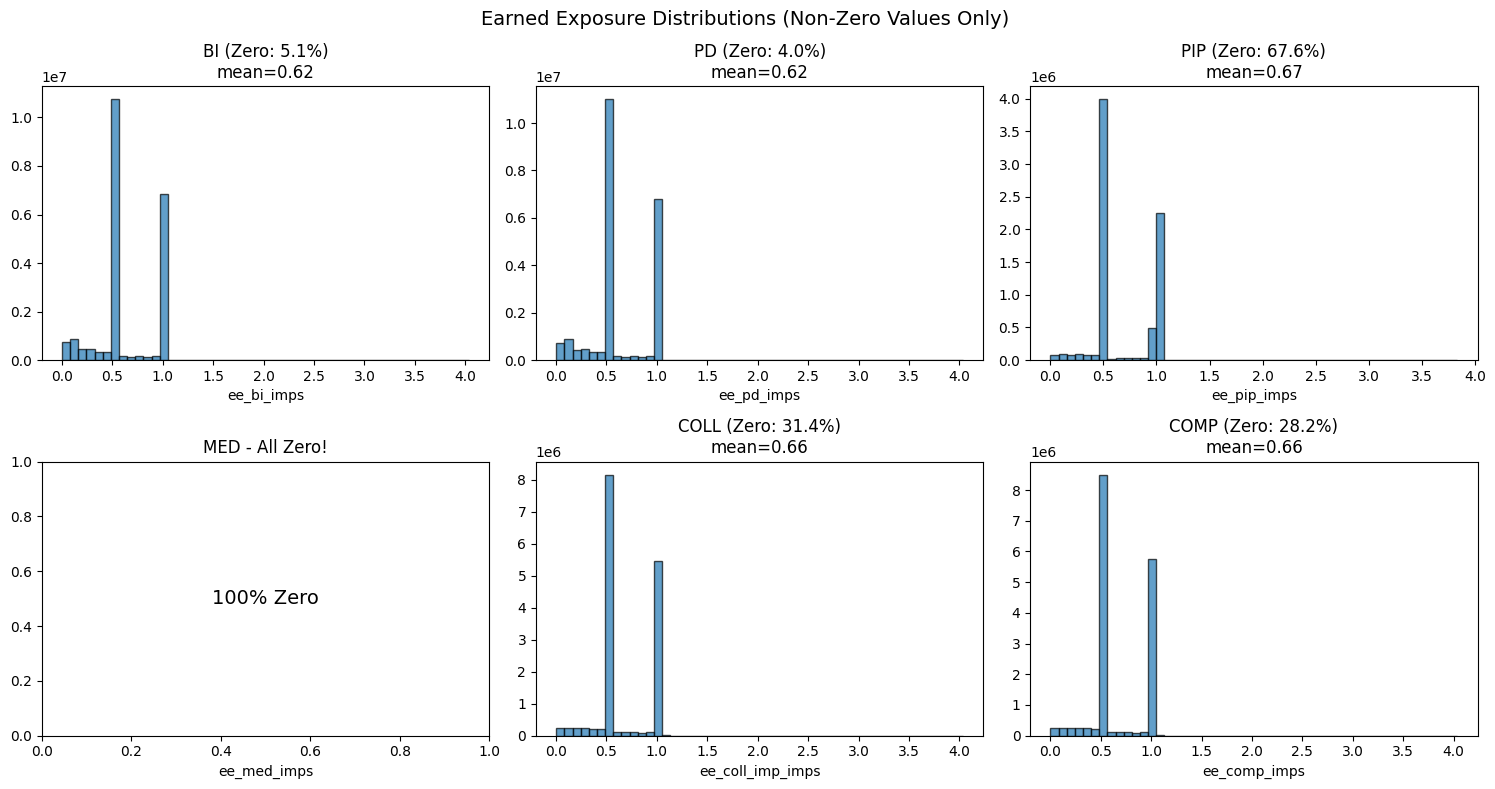


Summary of zero exposure:
  BI   : 1,154,153 zeros (5.1%)
  PD   : 900,360 zeros (4.0%)
  PIP  : 15,343,095 zeros (67.6%)
  MED  : 22,705,842 zeros (100.0%)
  COLL : 7,123,525 zeros (31.4%)
  COMP : 6,411,168 zeros (28.2%)


In [35]:
# Plot histograms of all 6 EE (Earned Exposure) columns
print("Earned Exposure Distributions for All 6 Coverages")
plot_all_coverage_histograms(df, config, coverages=config['all_coverages'])

Incurred Loss Distributions for All 6 Coverages


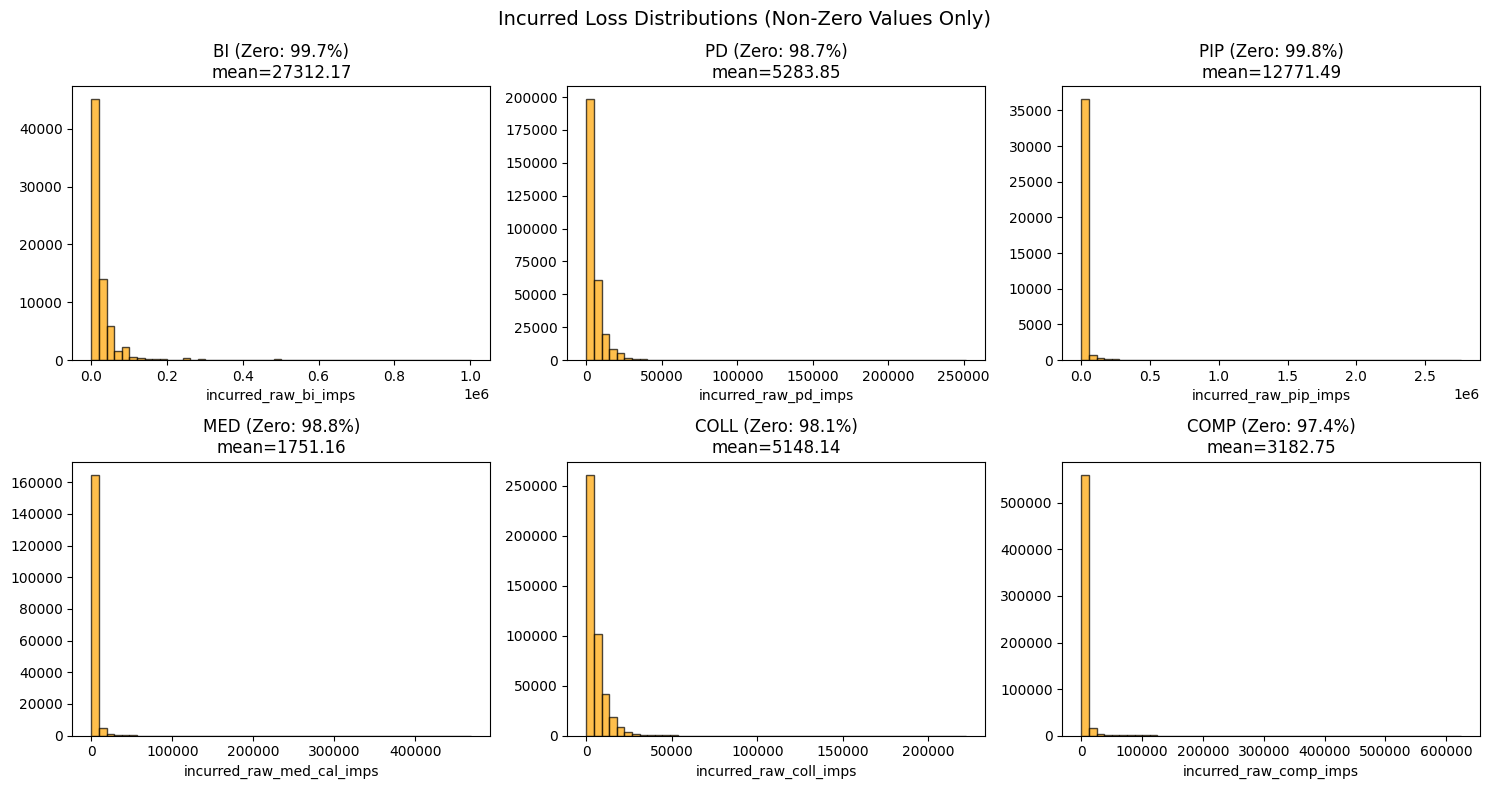


Summary of zero incurred:
  BI   : 22,634,039 zeros (99.7%)
  PD   : 22,407,744 zeros (98.7%)
  PIP  : 22,667,929 zeros (99.8%)
  MED  : 22,442,376 zeros (98.8%)
  COLL : 22,266,695 zeros (98.1%)
  COMP : 22,121,006 zeros (97.4%)


In [36]:
# Plot histograms of all 6 INCURRED loss columns
print("Incurred Loss Distributions for All 6 Coverages")
plot_incurred_histograms(df, config, coverages=config['all_coverages'])

### Coverage Analysis Notes

Based on the above histograms:

| Coverage | Description | Notes |
|----------|-------------|-------|
| BI | Bodily Injury | Primary liability coverage |
| PD | Property Damage | Primary liability coverage |
| PIP | Personal Injury Protection | State-dependent, may have high zeros |
| MED | Medical Payments | Often 100% zero - **excluded from objective** |
| COLL | Collision | Physical damage coverage |
| COMP | Comprehensive | Physical damage coverage |

The `objective_coverages` in `config.json` is set to `["bi", "pd", "pip", "coll", "comp"]` to exclude MED.

## 4. Analyze BI vs PD Relationship

This analysis helps determine if BI and PD should be:
- **Combined** into a single coverage for fold stratification
- **Treated separately** in the objective function

Key metrics:
- Correlation between BI and PD exposures
- Percentage of records where BI == PD
- Distribution of exposure differences


BI vs PD RELATIONSHIP ANALYSIS


/Users/Mach/dev/aps/code/26CF_Dmod_v1/add_data_folds/old_code/5fold_code/10fold_code/utils.py:768: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/Mach/anaconda3/envs/ds_stack_v1/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


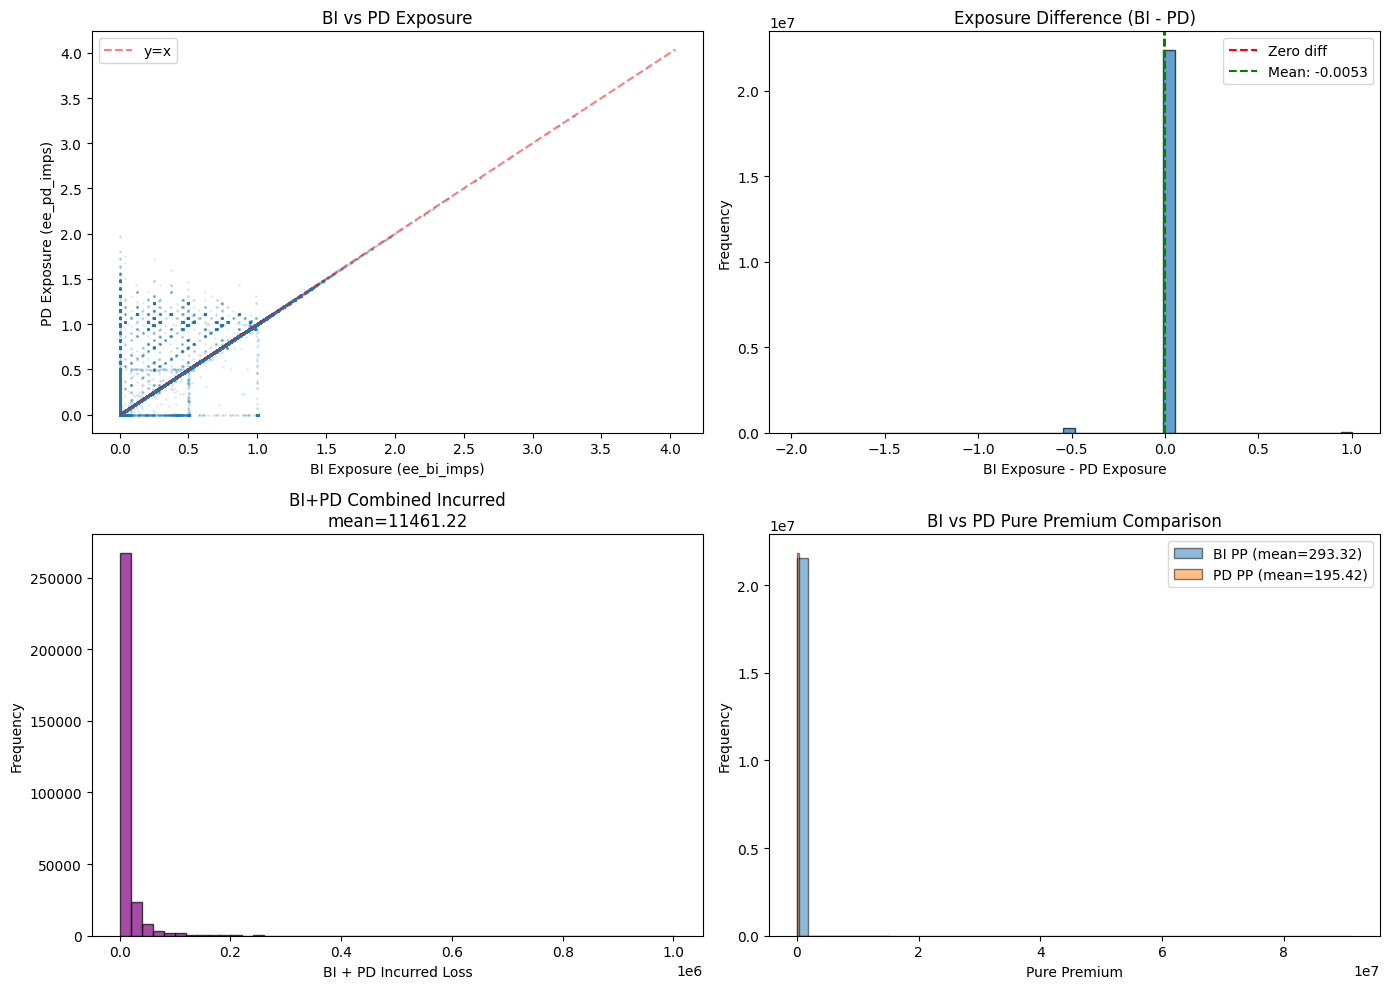


--- Summary Statistics ---

Exposure (EE):
  BI mean: 0.5910, sum: 13,418,674
  PD mean: 0.5963, sum: 13,538,789
  Correlation: 0.9728
  Mean difference (BI-PD): -0.0053
  Records where BI == PD: 22,370,143 (98.5%)

Incurred Loss:
  BI mean: 86.37, sum: 1,961,095,744
  PD mean: 69.37, sum: 1,575,104,753
  BI+PD mean: 155.74, sum: 3,536,200,497

Pure Premium:
  BI PP mean: 293.32
  PD PP mean: 195.42
  Combined PP (if BI+PD used): 263.53

--- Recommendation ---
  BI and PD exposures are nearly identical (>90% same).
  Consider treating them as the SAME exposure for fold stratification.


In [37]:
# Analyze BI vs PD relationship
analyze_bi_pd_relationship(df, config)

## 5. Zero Exposure Statistics

**Note:** All records are retained for fold assignment. Records with zero exposure for a coverage will have NaN Pure Premium for that coverage, but aggregate PP calculations handle this correctly.

In [38]:
# Show zero exposure statistics (no records removed)
# All records will be assigned to folds
show_zero_exposure_stats(df, config)


ZERO EXPOSURE STATISTICS (NO RECORDS REMOVED)

Total records: 22,705,842

Zero exposure counts by coverage:
  BI    (ee_bi_imps): 1,154,153 zeros (5.1%), 21,551,689 non-zero
  PD    (ee_pd_imps): 900,360 zeros (4.0%), 21,805,482 non-zero
  PIP   (ee_pip_imps): 15,343,095 zeros (67.6%), 7,362,747 non-zero
  MED   (ee_med_imps): 22,705,842 zeros (100.0%), 0 non-zero
  COLL  (ee_coll_imp_imps): 7,123,525 zeros (31.4%), 15,582,317 non-zero
  COMP  (ee_comp_imps): 6,411,168 zeros (28.2%), 16,294,674 non-zero

>>> All 22,705,842 records retained for fold assignment


In [39]:
# Verify all records retained
print(f"Data shape (all records retained): {df.shape}")
df.head()

Data shape (all records retained): (22705842, 14)


,vin_date,ee_bi_imps,ee_pd_imps,ee_pip_imps,ee_med_imps,ee_coll_imp_imps,ee_comp_imps,incurred_raw_bi_imps,incurred_raw_pd_imps,incurred_raw_pip_imps,incurred_raw_med_cal_imps,incurred_raw_coll_imps,incurred_raw_comp_imps,superpolicy_id
0,KMHWF35H45A178516_04-26-2022,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0
1,KMHWF35H75A128502_11-21-2020,0.117501,0.117501,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,KMHD35LE5DU068088_05-03-2020,0.155738,0.155738,0.000000,0.0,0.155738,0.155738,0.0,0.0,0.0,0.0,0.0,0.0,2
3,KMHD35LE5DU047158_05-30-2021,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3
4,KMHD35LE5DU082332_11-17-2019,0.497605,0.497605,0.497605,0.0,0.497605,0.497605,0.0,0.0,0.0,0.0,0.0,0.0,4


## 6. Calculate Pure Premium

In [40]:
# Calculate Pure Premium for each coverage in analysis_coverages
df = calculate_pure_premium(df, config)


CALCULATING PURE PREMIUM
Pure Premium columns created:
  pp_bi: mean=293.32, median=0.00
  pp_pd: mean=195.42, median=0.00
  pp_pip: mean=132.15, median=0.00
  pp_coll: mean=387.70, median=0.00
  pp_comp: mean=201.93, median=0.00


In [41]:
# Calculate overall statistics (uses objective_coverages)
overall_stats = calculate_overall_stats(df, config)
print_overall_stats(overall_stats, config=config)


--- Overall Statistics ---
  BI: PP=146.15, Weight=0.2533
  PD: PP=116.34, Weight=0.2556
  PIP: PP=97.85, Weight=0.0934
  COLL: PP=219.74, Weight=0.1942
  COMP: PP=172.67, Weight=0.2035


## 7. Run Simulations to Find Optimal Seed

In [42]:
# Run simulations
# Uses objective_coverages from config: ["bi", "pd", "pip", "coll", "comp"]
results_df = run_simulations(df, overall_stats, config=config)


RUNNING 300 SIMULATIONS (10 folds)
Objective coverages: ['bi', 'pd', 'pip', 'coll', 'comp']
  Completed 10/300 seeds... (elapsed: 109.9s, best so far: 1.5762)
  Completed 20/300 seeds... (elapsed: 216.9s, best so far: 1.5049)
  Completed 30/300 seeds... (elapsed: 332.9s, best so far: 1.5049)
  Completed 40/300 seeds... (elapsed: 450.0s, best so far: 1.3733)
  Completed 50/300 seeds... (elapsed: 565.1s, best so far: 1.3733)
  Completed 60/300 seeds... (elapsed: 681.9s, best so far: 1.3733)
  Completed 70/300 seeds... (elapsed: 797.0s, best so far: 1.3733)
  Completed 80/300 seeds... (elapsed: 909.1s, best so far: 1.3733)
  Completed 90/300 seeds... (elapsed: 1012.0s, best so far: 1.3733)
  Completed 100/300 seeds... (elapsed: 1115.0s, best so far: 1.3733)
  Completed 110/300 seeds... (elapsed: 1223.8s, best so far: 1.3733)
  Completed 120/300 seeds... (elapsed: 1326.4s, best so far: 1.3733)
  Completed 130/300 seeds... (elapsed: 1433.0s, best so far: 1.3733)
  Completed 140/300 seeds..

In [43]:
# View simulation results
results_df.head(10)

,seed,avg_objective,time_seconds,fold_1_obj,fold_2_obj,fold_3_obj,fold_4_obj,fold_5_obj,fold_6_obj,fold_7_obj,fold_8_obj,fold_9_obj,fold_10_obj
0,1,2.195049,12.513712,1.855545,2.770334,2.666154,3.495409,1.801800,1.798794,1.617513,1.197929,2.490220,2.256791
1,2,1.854674,11.985492,2.426068,1.571273,2.059710,2.257158,1.146749,1.807333,1.766044,2.218530,1.599846,1.694029
2,3,1.892755,10.837977,2.023317,2.736152,2.658452,2.763902,1.821740,0.948778,0.949013,1.555330,2.028775,1.442091
3,4,2.239498,10.452401,2.402950,1.954879,2.365264,1.516316,1.611242,1.782424,1.563701,2.074556,3.244543,3.879106
4,5,2.161175,10.872965,2.666427,2.110549,2.397942,1.463603,1.054321,3.650372,2.399205,2.053931,1.058557,2.756845
5,6,2.196770,11.550509,3.647456,2.708962,1.689093,2.452508,2.342781,1.845196,1.631964,2.123171,1.134652,2.391915
6,7,1.576204,10.730578,1.485909,1.095180,2.210209,1.494320,1.209903,1.815238,0.706297,1.837534,2.184844,1.722608
7,8,2.439917,10.511786,1.931799,2.654167,2.035168,2.009228,2.368244,3.931519,3.006452,1.378635,2.456761,2.627200
8,9,1.901036,10.380078,0.742906,3.327359,2.429322,2.325948,1.811558,1.273506,1.856687,2.225657,1.743309,1.274105
9,10,1.712873,10.068320,1.269468,1.488023,1.418029,2.173972,3.563860,1.935975,1.338128,1.320439,1.388830,1.232012


## 8. View Objective Function Distribution


OBJECTIVE FUNCTION DISTRIBUTION

Statistics:
  Min:    1.2951
  Max:    2.5962
  Mean:   1.9249
  Median: 1.9223
  Std:    0.2422


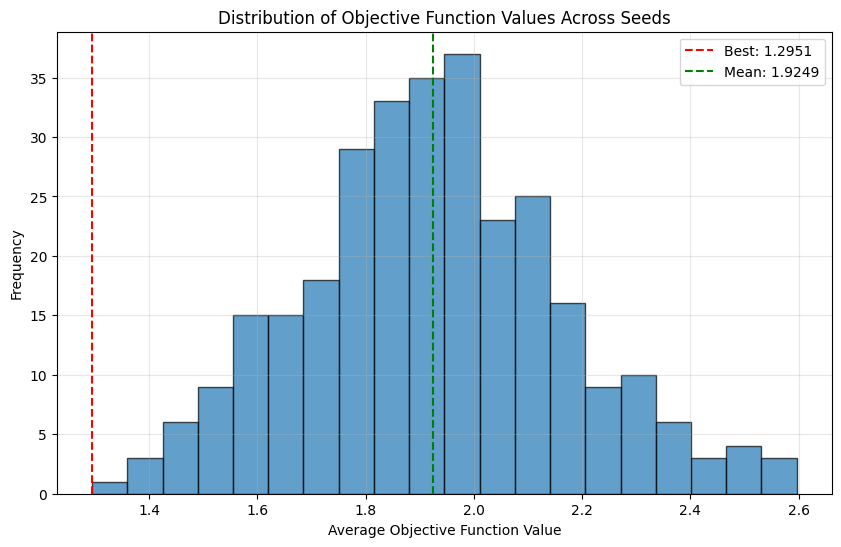

In [44]:
# Plot histogram of objective function values
plot_objective_distribution(results_df)

In [45]:
# Find the best seed
best_seed, best_obj = get_best_seed(results_df)


>>> BEST SEED: 222 (Objective: 1.2951)


## 9. Apply Best Seed and Assign Folds

In [46]:
# Assign folds using the best seed
df = assign_folds(df, best_seed, config)

print(f"\nFold distribution:")
print(df['fold'].value_counts().sort_index())


Fold distribution:
fold
1     2279525
2     2271005
3     2268245
4     2271221
5     2266625
6     2271464
7     2268113
8     2271441
9     2272527
10    2265676
Name: count, dtype: int64


## 10. Validate Fold Assignment

In [47]:
# Validate the fold assignment quality
validate_folds(df, overall_stats, config)


FOLD VALIDATION

--- Record Counts ---
  Fold 1: 2,279,525 records (10.0%)
  Fold 2: 2,271,005 records (10.0%)
  Fold 3: 2,268,245 records (10.0%)
  Fold 4: 2,271,221 records (10.0%)
  Fold 5: 2,266,625 records (10.0%)
  Fold 6: 2,271,464 records (10.0%)
  Fold 7: 2,268,113 records (10.0%)
  Fold 8: 2,271,441 records (10.0%)
  Fold 9: 2,272,527 records (10.0%)
  Fold 10: 2,265,676 records (10.0%)

--- Superpolicy Counts ---
  Fold 1: 421,900 superpolicies (10.0%)
  Fold 2: 421,900 superpolicies (10.0%)
  Fold 3: 421,900 superpolicies (10.0%)
  Fold 4: 421,900 superpolicies (10.0%)
  Fold 5: 421,900 superpolicies (10.0%)
  Fold 6: 421,900 superpolicies (10.0%)
  Fold 7: 421,900 superpolicies (10.0%)
  Fold 8: 421,900 superpolicies (10.0%)
  Fold 9: 421,900 superpolicies (10.0%)
  Fold 10: 421,901 superpolicies (10.0%)

--- Pure Premium by Fold vs Overall ---
Coverage        Overall     Fold 1     Fold 2     Fold 3     Fold 4     Fold 5     Fold 6     Fold 7     Fold 8     Fold 9    Fol

## 11. Save Output

In [48]:
# Save fold assignments and simulation results
df_output = save_output(df, simulation_results=results_df, config=config)


Simulation results saved to:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/simulation_results_10fold.csv

Fold assignments saved to:
  /Users/Mach/dev/aps/data/2026_Dmodel_data/fold_superpolicy/car_master_dataset_10fold_sp.parquet
  Shape: (22705842, 8)
  Columns: ['vin_date', 'superpolicy_id', 'fold', 'pp_bi', 'pp_pd', 'pp_pip', 'pp_coll', 'pp_comp']


In [49]:
# Preview final output
print(f"\nOutput preview:")
df_output.head(10)


Output preview:


,vin_date,superpolicy_id,fold,pp_bi,pp_pd,pp_pip,pp_coll,pp_comp
0,KMHWF35H45A178516_04-26-2022,0,4,0.0,0.0,NaN,0.0,0.0
1,KMHWF35H75A128502_11-21-2020,1,7,0.0,0.0,NaN,NaN,NaN
2,KMHD35LE5DU068088_05-03-2020,2,10,0.0,0.0,NaN,0.0,0.0
3,KMHD35LE5DU047158_05-30-2021,3,7,NaN,NaN,NaN,NaN,NaN
4,KMHD35LE5DU082332_11-17-2019,4,9,0.0,0.0,0.0,0.0,0.0
5,1HGCP3F81BA000806_05-11-2024,5,6,0.0,0.0,NaN,0.0,0.0
6,KMHD04LB4JU724186_07-24-2020,6,4,0.0,0.0,NaN,0.0,0.0
7,KMHWF35H83A750166_08-31-2021,7,4,0.0,0.0,NaN,0.0,0.0
8,KMHD35LE9DU147828_02-12-2021,8,8,0.0,0.0,NaN,0.0,0.0
9,KMHCU5AE3CU010071_10-19-2020,9,3,0.0,0.0,NaN,0.0,0.0


## Done!

The CAR 10-fold assignments have been saved. You can now merge this output back to your original data using `vin_date` as the join key.

In [50]:
# Example: How to merge back to original data
# original_data = pd.read_parquet("your_original_data.parquet")
# merged = pd.merge(original_data, df_output[['vin_date', 'fold']], on='vin_date', how='left')